In [1]:
import os
import random
import numpy as np
import torch
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings("ignore")

# ==========================================
# 🛑 CELL 1: DETERMINISTIC ENVIRONMENT SETUP
# ==========================================
def seed_everything(seed=42):
    """Locks all random number generators to ensure 100% reproducible results."""
    # Python & OS
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    
    # NumPy
    np.random.seed(seed)
    
    # PyTorch (CPU & GPU)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        # Force cuDNN to use deterministic algorithms
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

# Apply the global seed
SEED = 42
seed_everything(SEED)

# Define hardware device
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"✅ Environment locked. Global seed set to: {SEED}")
print(f"✅ Compute device set to: {DEVICE}")

✅ Environment locked. Global seed set to: 42
✅ Compute device set to: cuda


In [2]:
import torch.nn as nn

class HybridSASRec(nn.Module):
    def __init__(self, num_users, num_items, max_seq_len=20, embed_dim=64, num_heads=2, num_layers=2, dropout=0.3):
        super(HybridSASRec, self).__init__()
        
        self.user_embed = nn.Embedding(num_users, embed_dim)
        self.item_embed = nn.Embedding(num_items + 1, embed_dim, padding_idx=0) 
        self.pos_embed = nn.Embedding(max_seq_len, embed_dim)
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, 
            nhead=num_heads, 
            dropout=dropout, 
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
    def forward(self, users, seqs, target_item_idx):
        # 1. Embed the input sequence and add positional encodings
        seq_embeds = self.item_embed(seqs)
        positions = torch.arange(seqs.size(1), device=seqs.device).unsqueeze(0).expand_as(seqs)
        pos_embeds = self.pos_embed(positions)
        
        x = seq_embeds + pos_embeds
        padding_mask = (seqs == 0)
        
        # 2. Pass through Transformer & get final sequence state
        out = self.transformer(x, src_key_padding_mask=padding_mask)
        seq_reps = out[:, -1, :] 
        
        # 3. Get inherent User Embedding (acts like the MLP user state)
        u_reps = self.user_embed(users)
        
        # 4. Combine Collaborative User Rep + Sequential Rep
        combined_reps = seq_reps + u_reps
        
        # 5. Get embedding for the target item (positive or negative)
        item_reps = self.item_embed(target_item_idx)
        
        # 6. Dot product for final affinity score
        scores = (combined_reps * item_reps).sum(dim=1)
        return scores

print("SASRec architecture loaded")

SASRec architecture loaded


In [3]:
import os
import pickle
import joblib
import pandas as pd
import numpy as np
import torch
from scipy.sparse import load_npz
from sklearn.preprocessing import MinMaxScaler

class HybridRecommender:
    def __init__(self, artifact_dir, sasrec_dir, nb_dir, device='cuda'):
        print("⏳ Initializing Hybrid Engine and loading artifacts...")
        self.device = device
        
        # 1. Load Artifacts
        with open(os.path.join(artifact_dir, 'artifacts.pkl'), 'rb') as f:
            self.artifacts = pickle.load(f)
            
        self.n_books = len(self.artifacts['book_map'])
        self.reverse_book_map = {v: k for k, v in self.artifacts['book_map'].items()}
        self.book_indices = torch.arange(self.n_books, device=self.device)
        self.scaler = MinMaxScaler()
        
        # 2. Load DataFrames & Text Matrices
        self.books_df = pd.read_parquet(os.path.join(artifact_dir, 'books_clean.parquet'))
        self.tfidf_matrix = load_npz(os.path.join(artifact_dir, 'tfidf_matrix.npz'))
        
        # Setup Proficiency Labels
        level_map = {'Beginner (A2)': 0, 'Intermediate (B1)': 1, 'Advanced (B2)': 2, 'Expert (C1)': 3}
        self.books_df['proficiency_label'] = self.books_df['proficiency_level'].map(level_map)
        self.valid_nb_indices = set(self.books_df[self.books_df['proficiency_level'] != 'Unknown'].index.values)
        
        # 3. Initialize & Pre-compute Naïve Bayes
        self.nb_model = joblib.load(os.path.join(nb_dir, 'nb_proficiency_model.pkl'))
        self.nb_probs = self.nb_model.predict_proba(self.tfidf_matrix)
        
        # 4. Initialize & Load SASRec Collaborative Model
        sasrec_config = torch.load(os.path.join(sasrec_dir, 'sasrec_config_1.pt'), map_location=self.device)
        self.sasrec_model = HybridSASRec(
            num_users=sasrec_config['n_users'], 
            num_items=sasrec_config['n_books'], 
            embed_dim=sasrec_config['embed_dim'], 
            dropout=sasrec_config['dropout']
        ).to(self.device)
        
        self.sasrec_model.load_state_dict(torch.load(os.path.join(sasrec_dir, 'sasrec_bpr_weights_1.pt'), map_location=self.device))
        self.sasrec_model.eval()
        
        print("✅ Smart HybridRecommender Class compiled and loaded successfully!")

    @torch.no_grad()
    def get_sasrec_scores(self, user_idx, seq):
        """Gets Sequential scores from SASRec & scales them to [0, 1]"""
        # Pad sequence for inference
        input_seq = seq[-20:]
        padded_seq = [0] * (20 - len(input_seq)) + input_seq
        
        users_tensor = torch.tensor([user_idx], dtype=torch.long, device=self.device)
        seq_tensor = torch.tensor([padded_seq], dtype=torch.long, device=self.device)
        
        logits = self.sasrec_model(users_tensor, seq_tensor, self.book_indices).cpu().numpy().flatten()
        scaled_scores = self.scaler.fit_transform(logits.reshape(-1, 1)).flatten()
        return scaled_scores

    def get_user_preferred_level(self, seq):
        """Determines the user's dominant reading level from their history"""
        if not seq: 
            return 1 # Default to Intermediate (B1) if brand new user
            
        # Look up the proficiency labels of the books they've read
        read_levels = self.books_df.loc[seq, 'proficiency_label'].dropna()
        
        if len(read_levels) == 0:
            return 1

        # Return their most frequent reading level (0, 1, 2, or 3)
        return int(read_levels.mode()[0])

    def get_nb_scores(self, seq):
        """Content Score = Probability that the book matches the user's reading level"""
        preferred_level = self.get_user_preferred_level(seq)
        
        # Slice the probability matrix to get the scores for their specific level
        return self.nb_probs[:, preferred_level]

    def recommend(self, user_idx, alpha=0.9, top_k=10, seq=[]):
        """Fuses scores using alpha (SASRec weight) and 1-alpha (NB weight)"""
        sasrec_scores = self.get_sasrec_scores(user_idx, seq)
        nb_scores = self.get_nb_scores(seq)
        
        final_scores = np.zeros(self.n_books)
        
        for i in range(self.n_books):
            if i not in self.valid_nb_indices:
                final_scores[i] = sasrec_scores[i]
            else:
                nb_penalty = (alpha) + ((1 - alpha) * nb_scores[i])
                final_scores[i] = sasrec_scores[i] * nb_penalty
            
        if seq:
            final_scores[seq] = -float('inf')
            
        top_k_indices = np.argsort(final_scores)[::-1][:top_k]
        recommendations = [self.reverse_book_map[idx] for idx in top_k_indices]
        
        return recommendations, final_scores[top_k_indices]

print("✅ Smart HybridRecommender Class compiled successfully!")

✅ Smart HybridRecommender Class compiled successfully!


In [4]:
import os
import pandas as pd
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

# ==========================================
# 🤖 CELL 4: THE MASTER AGENT CLASS
# ==========================================
class BookBuddyAgent(HybridRecommender):
    def __init__(self, artifact_dir, sasrec_dir, nb_dir, device='cuda', llm_model_id="Qwen/Qwen2.5-7B-Instruct"):
        # 1. Initialize the Parent Class (Loads SASRec, Naïve Bayes, and Artifacts)
        super().__init__(artifact_dir, sasrec_dir, nb_dir, device=device)
        
        # 2. Load and Build User Reading Sequences Internally
        print("⏳ Building user reading histories for context...")
        train_df = pd.read_parquet(os.path.join(artifact_dir, 'train.parquet'))
        # Filter for positive interactions (rating >= 4) to build the sequences
        train_imp = train_df[train_df['rating'] >= 4][['user_idx', 'book_idx']]
        self.train_seqs = train_imp.sort_values('user_idx').groupby('user_idx')['book_idx'].apply(list).to_dict()
        
        self.level_map_reverse = {0: 'Beginner (A2)', 1: 'Intermediate (B1)', 2: 'Advanced (B2)', 3: 'Expert (C1)'}
        
        # 3. Initialize the LLM Engine (Stage 3)
        print(f"⏳ Loading Generative LLM: {llm_model_id} (Takes ~2 mins)...")
        bnb_config = BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_use_double_quant=True,
            bnb_4bit_quant_type="nf4",
            bnb_4bit_compute_dtype=torch.bfloat16
        )
        
        self.tokenizer = AutoTokenizer.from_pretrained(llm_model_id)
        self.llm = AutoModelForCausalLM.from_pretrained(
            llm_model_id,
            quantization_config=bnb_config,
            device_map="auto"
        )
        print("✅ BookBuddy Master Agent Fully Initialized!")

    def _build_context(self, seq, top_10_ids):
        """Internal method: Prepares text context for the LLM"""
        # User History Context
        history_titles = []
        
        # Dynamically identify the ID column
        id_col = self.artifacts.get('id_col', 'book_id')
        if id_col not in self.books_df.columns:
            id_col = 'goodreads_book_id' if 'goodreads_book_id' in self.books_df.columns else 'book_id'
            
        for idx in seq[-5:]:
            real_id = self.reverse_book_map[idx]
            title_matches = self.books_df.loc[self.books_df[id_col] == real_id, 'title'].values
            if len(title_matches) > 0:
                history_titles.append(title_matches[0])
                
        history_text = "\n".join([f"- {t}" for t in history_titles]) if history_titles else "No reading history available."
        
        # Candidates Context
        candidates_text = ""
        for i, book_id in enumerate(top_10_ids, 1):
            book = self.books_df[self.books_df[id_col] == book_id].iloc[0]
            candidates_text += f"{i}. Title: {book['title']} | Author: {book['authors']} | Genre: {book['genres_str']} | Level: {book['proficiency_level']}\n"
            
        return history_text, candidates_text

    def get_recommendations(self, user_idx):
        """Executes the full 3-Stage Pipeline for a given user"""
        
        # 1. Fetch user's sequence from internal dictionary
        seq = self.train_seqs.get(user_idx, [])
        
        # 2. RUN STAGE 1 & 2 (Inherited SASRec + NBC Fusion)
        top_10_ids, _ = self.recommend(user_idx=user_idx, seq=seq)
        
        # 3. Build Context & Identify Reading Level
        history_text, candidates_text = self._build_context(seq, top_10_ids)
        pref_level_idx = self.get_user_preferred_level(seq)
        user_level_name = self.level_map_reverse.get(pref_level_idx, "Unknown")
        
        # 4. Construct Generalized Reasoning Prompt
        messages = [
            {
                "role": "system", 
                "content": "You are 'BookBuddy', an expert and friendly book recommendation assistant. You analyze a reader's history and select the perfect books for them, ensuring the language complexity matches their comfort level."
            },
            {
                "role": "user", 
                "content": f"""I am looking for my next great book! My current reading proficiency is at the {user_level_name} level.

Here are the last few books I have read and enjoyed:
{history_text}

Here are 10 book candidates that match my reading level:
{candidates_text}

Task:
1. Select the BEST 3 books from the candidate list for my specific taste and reading level.
2. Output your response as a numbered list.
3. For each book, write a 1-to-2 sentence personalized justification. Reference the books I have already read to explain why this new book is a great fit for my interests and language proficiency.

Format exactly like this:
1. **[Book Title]** - [Your justification]"""
            }
        ]
        
        prompt = self.tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        inputs = self.tokenizer(prompt, return_tensors="pt").to(self.device)
        
        # 5. RUN STAGE 3 (LLM Re-ranking & Generation)
        with torch.no_grad():
            outputs = self.llm.generate(
                **inputs, 
                max_new_tokens=350, 
                temperature=0.7,
                do_sample=True,
                pad_token_id=self.tokenizer.eos_token_id
            )
        
        # Extract and return ONLY the generated text
        input_length = inputs['input_ids'].shape[1]
        response = self.tokenizer.decode(outputs[0][input_length:], skip_special_tokens=True)
        
        return response.strip()

print("✅ BookBuddyAgent Class compiled successfully!")

✅ BookBuddyAgent Class compiled successfully!


In [5]:
import random
import torch
import gc
# ==========================================
# 🚀 CELL 5: INITIALIZE AGENT
# ==========================================

# Note: This will load the Qwen model into VRAM, so it may take ~2 minutes.
book_buddy = BookBuddyAgent(
    artifact_dir='/kaggle/input/datasets/sherrytelli/bookbuddy-preprocessed/bookbuddy_artifacts', 
    sasrec_dir='/kaggle/input/models/sherrytelli/sasrec-bpr/pytorch/default/2', 
    nb_dir='/kaggle/input/models/sherrytelli/nbc/scikitlearn/default/1'
)

⏳ Initializing Hybrid Engine and loading artifacts...
✅ Smart HybridRecommender Class compiled and loaded successfully!
⏳ Building user reading histories for context...
⏳ Loading Generative LLM: Qwen/Qwen2.5-7B-Instruct (Takes ~2 mins)...


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

✅ BookBuddy Master Agent Fully Initialized!


In [6]:
import random

# ==========================================
# 🎲 CELL 6: GET RECOMMENDATIONS (RUN MULTIPLE TIMES)
# ==========================================

# 1. Select a Random User with a Reading History
valid_users = list(book_buddy.train_seqs.keys())
RANDOM_USER = random.choice(valid_users)
n_read = len(book_buddy.train_seqs[RANDOM_USER])

print("\n" + "="*80)
print(f"📚 BOOKBUDDY PIPELINE FOR RANDOM USER: {RANDOM_USER} ({n_read} books read)")
print("="*80)
print("⏳ Analyzing history and generating personalized recommendations...\n")

# 2. Generate the Final Explainable Recommendation
final_recommendations = book_buddy.get_recommendations(user_idx=RANDOM_USER)

# 3. Display Results
print(final_recommendations)
print("\n" + "="*80)


📚 BOOKBUDDY PIPELINE FOR RANDOM USER: 41922 (46 books read)
⏳ Analyzing history and generating personalized recommendations...

1. **To Kill a Mockingbird** - This classic novel by Harper Lee explores themes of racial injustice and moral growth, much like "The Grapes of Wrath" and "Grendel," which you have enjoyed. It's written in accessible language, making it perfect for your reading level.

2. **The Help** - Similar to "Dress Your Family in Corduroy and Denim," this novel by Kathryn Stockett delves into complex social issues through the eyes of its characters. Its narrative style and vocabulary will be familiar and engaging for you.

3. **The Fellowship of the Ring** - As a fan of fantasy, you might appreciate the epic journey and mythical elements in this first book of "The Lord of the Rings" series. It’s written in a way that’s suitable for beginners, with a rich yet understandable language, much like "The Wonderful Wizard of Oz."



# Evaluation framework

In [7]:
# ==========================================
# 🛠️ CELL 7: API SETUP & IMPORTS
# ==========================================
!pip install -q cohere google-generativeai

import time
import gc
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from kaggle_secrets import UserSecretsClient
import cohere
import google.generativeai as genai

# Safely load API keys from Kaggle Secrets
try:
    user_secrets = UserSecretsClient()
    cohere_api_key = user_secrets.get_secret("COHERE_API_KEY")
    genai.configure(api_key=user_secrets.get_secret("GEMINI_API_KEY"))
    print("✅ API Keys loaded successfully.")
except Exception as e:
    print(f"⚠️ Warning: Could not load API keys. Ensure they are set in Kaggle Secrets. Error: {e}")

# Initialize Cohere Client
cohere_client = cohere.Client(api_key=cohere_api_key)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 351.8/351.8 kB 2.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 22.2 MB/s eta 0:00:0000:0100:01
✅ API Keys loaded successfully.


In [8]:
# ==========================================
# 🔀 CELL 8: UNIVERSAL LLM ROUTER
# ==========================================
def generate_llm_response(prompt, model_name, local_model=None, local_tokenizer=None):
    """Routes the prompt to the correct model and returns (text, prompt_tokens, completion_tokens)."""
    
    # 1. COHERE (Command-R)
    if "command" in model_name.lower():
        response = cohere_client.chat(
            model=model_name,
            message=prompt,
            temperature=0.7,
            max_tokens=350
        )
        text = response.text
        # Extract token counts securely
        try:
            p_tokens = response.meta.billed_units.input_tokens
            c_tokens = response.meta.billed_units.output_tokens
        except AttributeError:
            p_tokens, c_tokens = 0, 0 # Fallback if metadata is missing
            
        return text, p_tokens, c_tokens
        
    # 2. GOOGLE (Gemini-1.5-Flash)
    elif "gemini" in model_name.lower():
        model = genai.GenerativeModel(model_name)
        response = model.generate_content(prompt, generation_config={"temperature": 0.7, "max_output_tokens": 350})
        text = response.text
        # Gemini API provides token counts via metadata
        p_tokens = response.usage_metadata.prompt_token_count
        c_tokens = response.usage_metadata.candidates_token_count
        return text, p_tokens, c_tokens
        
    # 3. LOCAL OPEN-SOURCE MODELS (Qwen, Phi-3, Mistral)
    elif local_model is not None and local_tokenizer is not None:
        messages = [{"role": "user", "content": prompt}]
        formatted_prompt = local_tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        inputs = local_tokenizer(formatted_prompt, return_tensors="pt").to(DEVICE)
        
        input_length = inputs['input_ids'].shape[1]
        
        with torch.no_grad():
            outputs = local_model.generate(
                **inputs, 
                max_new_tokens=350, 
                temperature=0.7,
                do_sample=True,
                pad_token_id=local_tokenizer.eos_token_id
            )
            
        generated_tokens = outputs[0][input_length:]
        text = local_tokenizer.decode(generated_tokens, skip_special_tokens=True)
        
        return text.strip(), input_length, len(generated_tokens)
        
    else:
        raise ValueError(f"Model configuration for {model_name} is invalid.")

print("✅ Universal LLM Router compiled.")

✅ Universal LLM Router compiled.


In [9]:
# ==========================================
# ⚖️ CELL 9: HALLUCINATION DETECTOR
# ==========================================
def evaluate_hallucination(response_text, valid_candidate_titles):
    """
    Checks if the recommended books are actually in the candidate list.
    Returns the number of valid recommendations and a boolean flag (True if it hallucinated).
    """
    valid_count = 0
    # Clean the response text for easier matching (lowercase, remove punctuation)
    clean_response = re.sub(r'[^\w\s]', '', response_text.lower())
    
    for title in valid_candidate_titles:
        clean_title = re.sub(r'[^\w\s]', '', title.lower())
        if clean_title in clean_response:
            valid_count += 1
            
    # If the model didn't recommend at least 3 books from the list, we flag it as hallucinating or failing instructions.
    hallucinated = 1 if valid_count < 3 else 0
    return valid_count, hallucinated

print("✅ Evaluator compiled.")

✅ Evaluator compiled.


In [10]:
# ==========================================
# 🚀 CELL 10: VRAM-MANAGED EVALUATION LOOP
# ==========================================
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

# 1. Setup Evaluation Parameters
NUM_TEST_USERS = 20 # Adjust this based on how much time you have
sample_users = random.sample(valid_users, NUM_TEST_USERS)
results_data = []

# 2. Extract Prompt Builder from your Agent
def build_eval_prompt_and_candidates(user_idx):
    seq = book_buddy.train_seqs.get(user_idx, [])
    top_10_ids, _ = book_buddy.recommend(user_idx=user_idx, seq=seq)
    history_text, candidates_text = book_buddy._build_context(seq, top_10_ids)
    
    pref_level_idx = book_buddy.get_user_preferred_level(seq)
    user_level_name = book_buddy.level_map_reverse.get(pref_level_idx, "Unknown")
    
    prompt = f"""I am looking for my next great book! My current reading proficiency is at the {user_level_name} level.

Here are the last few books I have read and enjoyed:
{history_text}

Here are 10 book candidates that match my reading level:
{candidates_text}

Task:
1. Select the BEST 3 books from the candidate list for my specific taste and reading level.
2. Output your response as a numbered list.
3. For each book, write a 1-to-2 sentence personalized justification."""

    # Extract valid titles for hallucination checking
    id_col = book_buddy.artifacts.get('id_col', 'book_id')
    if id_col not in book_buddy.books_df.columns:
        id_col = 'goodreads_book_id' if 'goodreads_book_id' in book_buddy.books_df.columns else 'book_id'
        
    valid_titles = []
    for book_id in top_10_ids:
        title = book_buddy.books_df.loc[book_buddy.books_df[id_col] == book_id, 'title'].values[0]
        valid_titles.append(title)

    return prompt, valid_titles

# 3. Test API Models First (No VRAM needed)
api_models = ["command-r-08-2024", "gemini-2.5-flash"]

for model_name in api_models:
    print(f"\n🌐 Evaluating API Model: {model_name}...")
    for user_idx in sample_users:
        prompt, valid_titles = build_eval_prompt_and_candidates(user_idx)
        
        start_time = time.time()
        try:
            response, p_tokens, c_tokens = generate_llm_response(prompt, model_name)
            latency = time.time() - start_time
            valid_count, is_hallucinated = evaluate_hallucination(response, valid_titles)
            
            results_data.append({
                "User": user_idx, "Model": model_name, "Latency_Sec": latency,
                "Prompt_Tokens": p_tokens, "Completion_Tokens": c_tokens,
                "Valid_Recs": valid_count, "Hallucinated": is_hallucinated
            })
        except Exception as e:
            print(f"Error with {model_name} for user {user_idx}: {e}")

# 4. Define Open-Source Models to Test
os_models = [
    "Qwen/Qwen2.5-7B-Instruct", 
    "mistralai/Mistral-7B-Instruct-v0.2",
    "microsoft/Phi-3-mini-4k-instruct"
]

# 5. Clear existing VRAM (Delete the BookBuddy Qwen instance)
print("\n🧹 Clearing VRAM before loading open-source models...")
if hasattr(book_buddy, 'llm'):
    del book_buddy.llm
    del book_buddy.tokenizer
gc.collect()
torch.cuda.empty_cache()

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True, bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4", bnb_4bit_compute_dtype=torch.bfloat16
)

# 6. Loop, Load, Evaluate, and Delete Open-Source Models
for model_id in os_models:
    print(f"\n🖥️ Loading Local Model: {model_id}...")
    # Added trust_remote_code=True for maximum compatibility with Phi-3
    tokenizer = AutoTokenizer.from_pretrained(model_id, trust_remote_code=True)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
        
    model = AutoModelForCausalLM.from_pretrained(
        model_id, 
        quantization_config=bnb_config, 
        device_map="auto",
    )
    
    print(f"▶️ Evaluating {model_id}...")
    for user_idx in sample_users:
        prompt, valid_titles = build_eval_prompt_and_candidates(user_idx)
        
        start_time = time.time()
        response, p_tokens, c_tokens = generate_llm_response(prompt, model_id, local_model=model, local_tokenizer=tokenizer)
        latency = time.time() - start_time
        
        valid_count, is_hallucinated = evaluate_hallucination(response, valid_titles)
        
        results_data.append({
            "User": user_idx, "Model": model_id.split('/')[-1], "Latency_Sec": latency,
            "Prompt_Tokens": p_tokens, "Completion_Tokens": c_tokens,
            "Valid_Recs": valid_count, "Hallucinated": is_hallucinated
        })
        
    # 🚨 CRITICAL VRAM MANAGEMENT
    print(f"🧹 Unloading {model_id} to free VRAM...")
    del model
    del tokenizer
    gc.collect()
    torch.cuda.empty_cache()

# Save results to DataFrame
results_df = pd.DataFrame(results_data)
print("\n✅ Evaluation Complete! Results saved to results_df.")


🌐 Evaluating API Model: command-r-08-2024...

🌐 Evaluating API Model: gemini-2.5-flash...
Error with gemini-2.5-flash for user 48567: 429 You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 5, model: gemini-2.5-flash
Please retry in 53.888376337s. [links {
  description: "Learn more about Gemini API quotas"
  url: "https://ai.google.dev/gemini-api/docs/rate-limits"
}
, violations {
  quota_metric: "generativelanguage.googleapis.com/generate_content_free_tier_requests"
  quota_id: "GenerateRequestsPerMinutePerProjectPerModel-FreeTier"
  quota_dimensions {
    key: "model"
    value: "gemini-2.5-flash"
  }
  quota_dimensions {
    key: "location"
    value: "global"
  }
  quota_value: 5
}
, retry

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

▶️ Evaluating Qwen/Qwen2.5-7B-Instruct...
🧹 Unloading Qwen/Qwen2.5-7B-Instruct to free VRAM...

🖥️ Loading Local Model: mistralai/Mistral-7B-Instruct-v0.2...


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

▶️ Evaluating mistralai/Mistral-7B-Instruct-v0.2...
🧹 Unloading mistralai/Mistral-7B-Instruct-v0.2 to free VRAM...

🖥️ Loading Local Model: microsoft/Phi-3-mini-4k-instruct...


Loading weights:   0%|          | 0/195 [00:00<?, ?it/s]

▶️ Evaluating microsoft/Phi-3-mini-4k-instruct...
🧹 Unloading microsoft/Phi-3-mini-4k-instruct to free VRAM...

✅ Evaluation Complete! Results saved to results_df.


🏆 EVALUATION SUMMARY 🏆


,Model,Avg_Latency,Avg_Completion_Tokens,Hallucination_Rate,Avg_Valid_Recs
0,Mistral-7B-Instruct-v0.2,27.197844,234.45,0.3,2.70
1,Phi-3-mini-4k-instruct,14.595298,194.20,0.1,2.80
2,Qwen2.5-7B-Instruct,22.078976,216.25,0.0,3.05
3,command-r-08-2024,24.279045,216.30,0.2,2.60
4,gemini-2.5-flash,2.712797,12.60,1.0,0.00


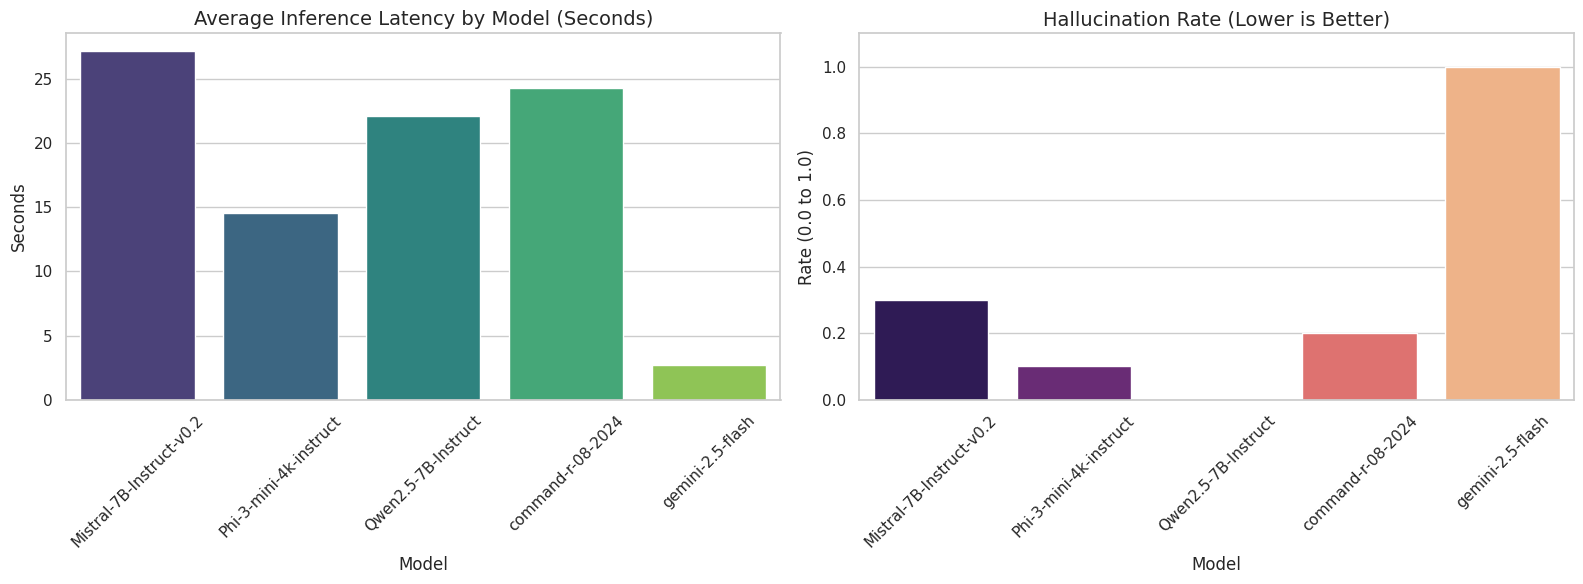

In [11]:
# ==========================================
# 📊 CELL 11: RESULTS & VISUALIZATION
# ==========================================
# Calculate Aggregates
summary_df = results_df.groupby('Model').agg(
    Avg_Latency=('Latency_Sec', 'mean'),
    Avg_Completion_Tokens=('Completion_Tokens', 'mean'),
    Hallucination_Rate=('Hallucinated', 'mean'),
    Avg_Valid_Recs=('Valid_Recs', 'mean')
).reset_index()

print("🏆 EVALUATION SUMMARY 🏆")
display(summary_df)

# Plotting
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Latency Comparison
sns.barplot(data=summary_df, x='Model', y='Avg_Latency', ax=axes[0], palette="viridis")
axes[0].set_title("Average Inference Latency by Model (Seconds)", fontsize=14)
axes[0].set_ylabel("Seconds")
axes[0].tick_params(axis='x', rotation=45)

# Plot 2: Hallucination Rate
sns.barplot(data=summary_df, x='Model', y='Hallucination_Rate', ax=axes[1], palette="magma")
axes[1].set_title("Hallucination Rate (Lower is Better)", fontsize=14)
axes[1].set_ylabel("Rate (0.0 to 1.0)")
axes[1].set_ylim(0, 1.1)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()